In [1]:
from pathlib import Path
import base64
import io
import json
import random
import zlib
from typing import Dict, List, Optional, Tuple

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

# Root folders
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "dataset"
META_PATH = DATASET_ROOT / "meta.json"

if not META_PATH.exists():
    # Fallback in case notebook is launched from parent folder
    PROJECT_ROOT = PROJECT_ROOT / "HSS Project"
    DATASET_ROOT = PROJECT_ROOT / "dataset"
    META_PATH = DATASET_ROOT / "meta.json"

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

classes = meta["classes"]
class_id_to_train_id: Dict[int, int] = {}
train_id_to_class_name: Dict[int, str] = {0: "background"}
train_id_to_color: Dict[int, Tuple[int, int, int]] = {0: (0, 0, 0)}

for idx, cls in enumerate(classes, start=1):
    class_id_to_train_id[cls["id"]] = idx
    train_id_to_class_name[idx] = cls["title"]
    color_hex = cls.get("color", "#FFFFFF").lstrip("#")
    train_id_to_color[idx] = tuple[int, int, int](int(color_hex[i:i+2], 16) for i in (0, 2, 4))

print(f"Dataset root: {DATASET_ROOT}")
print(f"Classes: {len(classes)} (+ background)")

Dataset root: u:\Dev\AI\HSS Project\dataset
Classes: 103 (+ background)


In [2]:
def decode_bitmap_to_canvas(bitmap_data: str, origin: List[int], canvas_h: int, canvas_w: int) -> np.ndarray:
    """Decode Supervisely-style bitmap into a full-size binary mask."""
    packed_bytes = base64.b64decode(bitmap_data)

    # FoodSeg/Supervisely stores zlib-compressed PNG bytes in bitmap.data.
    try:
        png_bytes = zlib.decompress(packed_bytes)
    except zlib.error:
        # Fallback for already-uncompressed payloads.
        png_bytes = packed_bytes

    bitmap = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
    bitmap_arr = np.array(bitmap)

    # Alpha channel carries the actual bitmap region.
    local_mask = bitmap_arr[..., 3] > 0

    x0, y0 = int(origin[0]), int(origin[1])
    h, w = local_mask.shape

    canvas = np.zeros((canvas_h, canvas_w), dtype=bool)

    x1 = max(0, x0)
    y1 = max(0, y0)
    x2 = min(canvas_w, x0 + w)
    y2 = min(canvas_h, y0 + h)

    if x1 >= x2 or y1 >= y2:
        return canvas

    src_x1 = x1 - x0
    src_y1 = y1 - y0
    src_x2 = src_x1 + (x2 - x1)
    src_y2 = src_y1 + (y2 - y1)

    canvas[y1:y2, x1:x2] = local_mask[src_y1:src_y2, src_x1:src_x2]
    return canvas


class FoodSegDataset(Dataset):
    def __init__(
        self,
        dataset_root: Path,
        split: str = "train",
        class_id_to_train_id: Optional[Dict[int, int]] = None,
        augment: bool = False,
        hflip_prob: float = 0.5,
        vflip_prob: float = 0.0,
        rot90_prob: float = 0.3,
        brightness_prob: float = 0.3,
        brightness_strength: float = 0.2,
        seed: Optional[int] = None,
    ):
        assert split in {"train", "test"}, "split must be 'train' or 'test'"
        self.dataset_root = Path(dataset_root)
        self.split = split
        self.img_dir = self.dataset_root / split / "img"
        self.ann_dir = self.dataset_root / split / "ann"

        self.class_id_to_train_id = class_id_to_train_id or {}
        self.augment = augment and split == "train"
        self.hflip_prob = hflip_prob
        self.vflip_prob = vflip_prob
        self.rot90_prob = rot90_prob
        self.brightness_prob = brightness_prob
        self.brightness_strength = brightness_strength
        self.rng = random.Random(seed)

        self.samples = []
        for ann_path in sorted(self.ann_dir.glob("*.json")):
            img_name = ann_path.name.replace(".json", "")
            img_path = self.img_dir / img_name
            if img_path.exists():
                self.samples.append((img_path, ann_path))

        if len(self.samples) == 0:
            raise RuntimeError(f"No samples found for split={split} in {self.dataset_root}")

    def __len__(self) -> int:
        return len(self.samples)

    def _build_mask_from_annotation(self, ann: dict) -> np.ndarray:
        h = int(ann["size"]["height"])
        w = int(ann["size"]["width"])
        sem_mask = np.zeros((h, w), dtype=np.int64)

        for obj in ann.get("objects", []):
            if obj.get("geometryType") != "bitmap":
                continue
            bitmap = obj.get("bitmap")
            if bitmap is None:
                continue

            class_id = obj.get("classId")
            train_id = self.class_id_to_train_id.get(class_id, 0)
            obj_mask = decode_bitmap_to_canvas(
                bitmap_data=bitmap["data"],
                origin=bitmap["origin"],
                canvas_h=h,
                canvas_w=w,
            )
            sem_mask[obj_mask] = train_id

        return sem_mask

    def _apply_augmentations(self, image: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        # Geometric transforms must be applied to image and mask together.
        if self.rng.random() < self.hflip_prob:
            image = np.ascontiguousarray(np.fliplr(image))
            mask = np.ascontiguousarray(np.fliplr(mask))

        if self.rng.random() < self.vflip_prob:
            image = np.ascontiguousarray(np.flipud(image))
            mask = np.ascontiguousarray(np.flipud(mask))

        if self.rng.random() < self.rot90_prob:
            k = self.rng.choice([1, 2, 3])
            image = np.ascontiguousarray(np.rot90(image, k=k))
            mask = np.ascontiguousarray(np.rot90(mask, k=k))

        # Photometric transform is image-only.
        if self.rng.random() < self.brightness_prob:
            factor = 1.0 + self.rng.uniform(-self.brightness_strength, self.brightness_strength)
            image = np.clip(image.astype(np.float32) * factor, 0, 255).astype(np.uint8)

        return image, mask

    def __getitem__(self, idx: int):
        img_path, ann_path = self.samples[idx]

        image = np.array(Image.open(img_path).convert("RGB"), dtype=np.uint8)
        with open(ann_path, "r", encoding="utf-8") as f:
            ann = json.load(f)

        mask = self._build_mask_from_annotation(ann)

        if self.augment:
            image, mask = self._apply_augmentations(image, mask)

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask_tensor = torch.from_numpy(mask).long()

        sample_info = {
            "image_path": str(img_path),
            "annotation_path": str(ann_path),
            "split": self.split,
            "index": idx,
        }
        return image_tensor, mask_tensor, sample_info

In [3]:
def colorize_mask(mask: np.ndarray, train_id_to_color: Dict[int, Tuple[int, int, int]]) -> np.ndarray:
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for train_id in np.unique(mask):
        color = train_id_to_color.get(int(train_id), (255, 255, 255))
        color_mask[mask == train_id] = color

    return color_mask


def overlay_image_with_mask(image: np.ndarray, color_mask: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    image_f = image.astype(np.float32)
    mask_f = color_mask.astype(np.float32)
    overlay = np.clip((1.0 - alpha) * image_f + alpha * mask_f, 0, 255).astype(np.uint8)
    return overlay


def show_sample(
    image_tensor: torch.Tensor,
    mask_tensor: torch.Tensor,
    train_id_to_class_name: Dict[int, str],
    train_id_to_color: Dict[int, Tuple[int, int, int]],
    alpha: float = 0.45,
    max_legend_items: int = 15,
):
    image = (image_tensor.permute(1, 2, 0).cpu().numpy() * 255.0).clip(0, 255).astype(np.uint8)
    mask = mask_tensor.cpu().numpy().astype(np.int64)

    color_mask = colorize_mask(mask, train_id_to_color)
    overlay = overlay_image_with_mask(image, color_mask, alpha=alpha)

    uniq_ids = [int(x) for x in np.unique(mask) if int(x) != 0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(color_mask)
    axes[1].set_title("Mask (colorized)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    if len(uniq_ids) > 0:
        legend_items = []
        for train_id in uniq_ids[:max_legend_items]:
            name = train_id_to_class_name.get(train_id, f"class_{train_id}")
            legend_items.append(f"{train_id}: {name}")

        legend_title = "Classes in sample"
        if len(uniq_ids) > max_legend_items:
            legend_title += f" (first {max_legend_items})"

        fig.suptitle(" | ".join(legend_items), fontsize=10, y=1.03)

    plt.tight_layout()
    plt.show()

In [4]:
train_ds = FoodSegDataset(
    dataset_root=DATASET_ROOT,
    split="train",
    class_id_to_train_id=class_id_to_train_id,
    augment=True,
    hflip_prob=0.5,
    vflip_prob=0.1,
    rot90_prob=0.25,
    brightness_prob=0.35,
    brightness_strength=0.2,
    seed=42,
)

test_ds = FoodSegDataset(
    dataset_root=DATASET_ROOT,
    split="test",
    class_id_to_train_id=class_id_to_train_id,
    augment=False,
)

print(f"train samples: {len(train_ds)}")
print(f"test samples:  {len(test_ds)}")

train samples: 4983
test samples:  2135


Sample info: {'image_path': 'u:\\Dev\\AI\\HSS Project\\dataset\\train\\img\\00000000.jpg', 'annotation_path': 'u:\\Dev\\AI\\HSS Project\\dataset\\train\\ann\\00000000.jpg.json', 'split': 'train', 'index': 0}
Image shape: (3, 384, 512)
Mask shape: (384, 512)
Unique class ids (sample): [0, 22, 81, 89] 


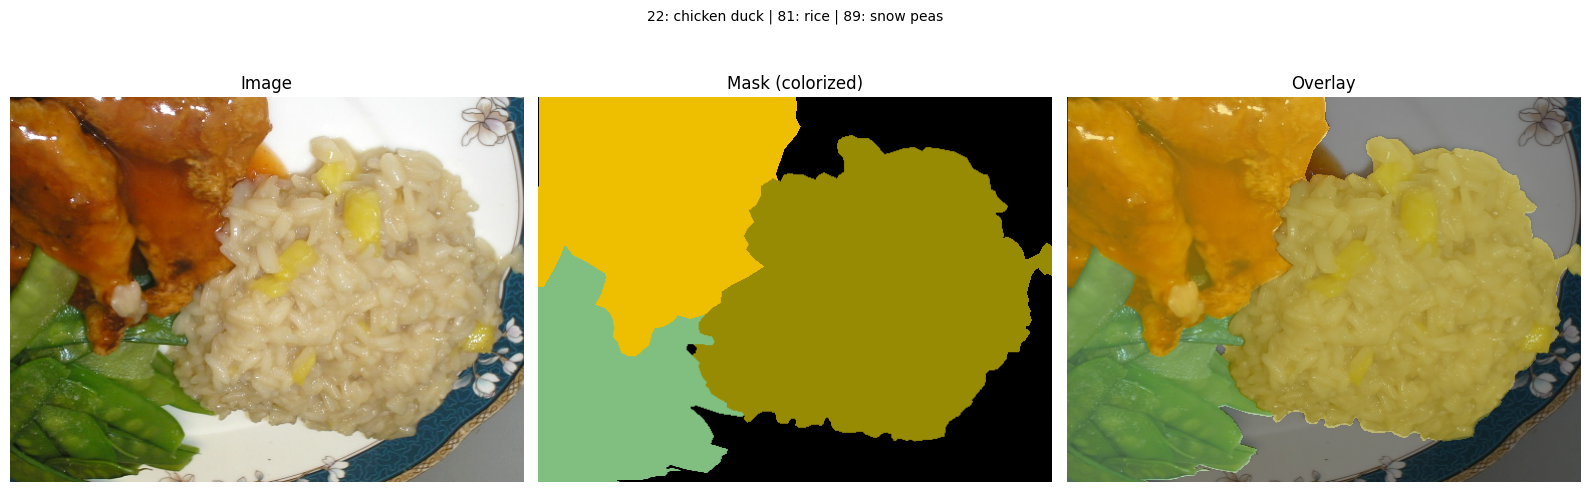

In [5]:
# Sanity-check for one train sample
img_t, mask_t, info = train_ds[0]

assert img_t.ndim == 3 and img_t.shape[0] == 3, "Image tensor must be [3, H, W]"
assert mask_t.ndim == 2, "Mask tensor must be [H, W]"
assert img_t.shape[1:] == mask_t.shape, "Image and mask spatial sizes must match"
assert img_t.dtype == torch.float32, "Image dtype must be float32"
assert mask_t.dtype == torch.int64, "Mask dtype must be int64"

uniq = torch.unique(mask_t).cpu().numpy().tolist()
print("Sample info:", info)
print("Image shape:", tuple(img_t.shape))
print("Mask shape:", tuple(mask_t.shape))
print("Unique class ids (sample):", uniq[:30], "..." if len(uniq) > 30 else "")

show_sample(img_t, mask_t, train_id_to_class_name, train_id_to_color, alpha=0.45)

Train examples
idx=428 | 00000430.jpg


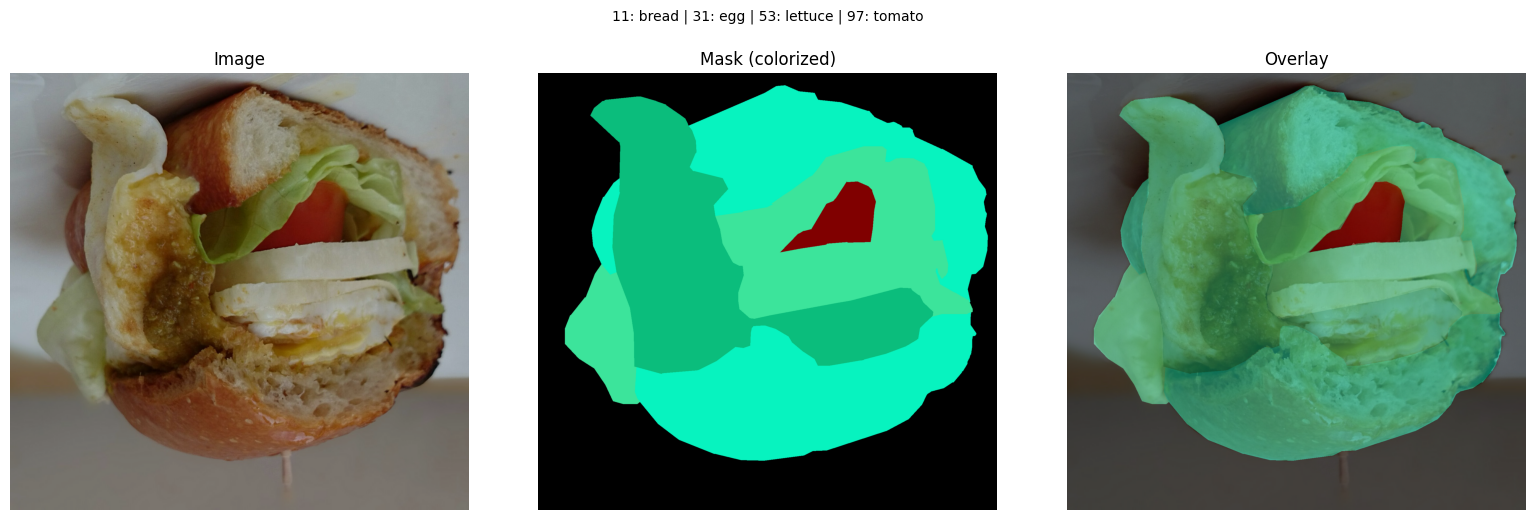

idx=2192 | 00002196.jpg


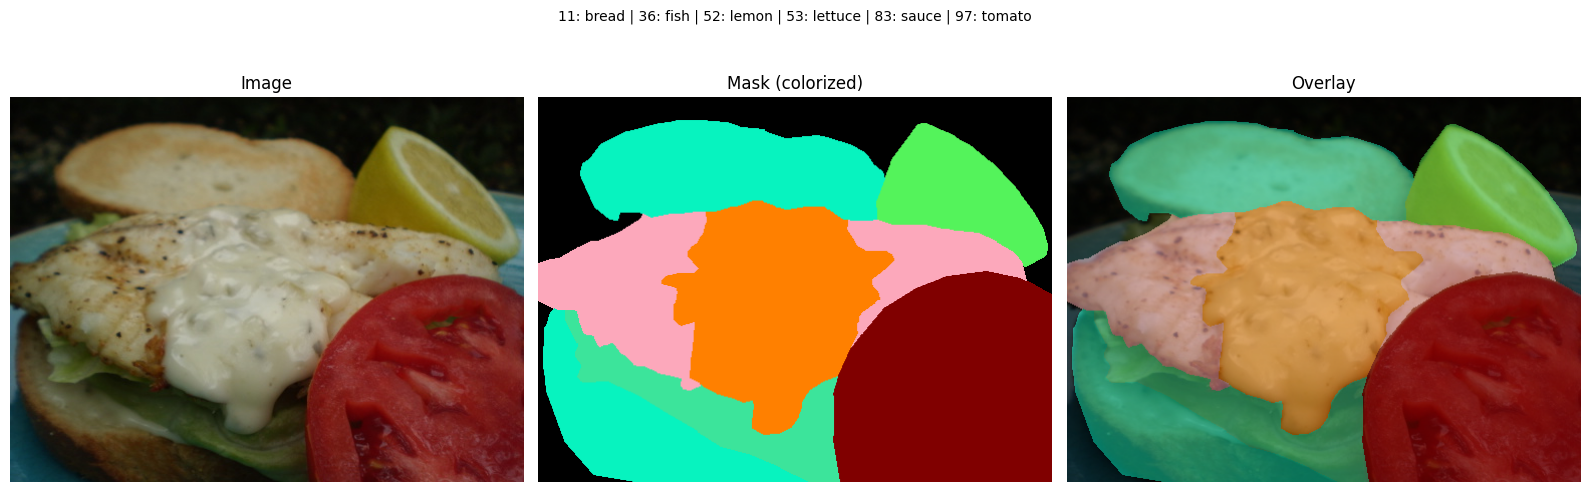

Test examples
idx=357 | 00004754.jpg


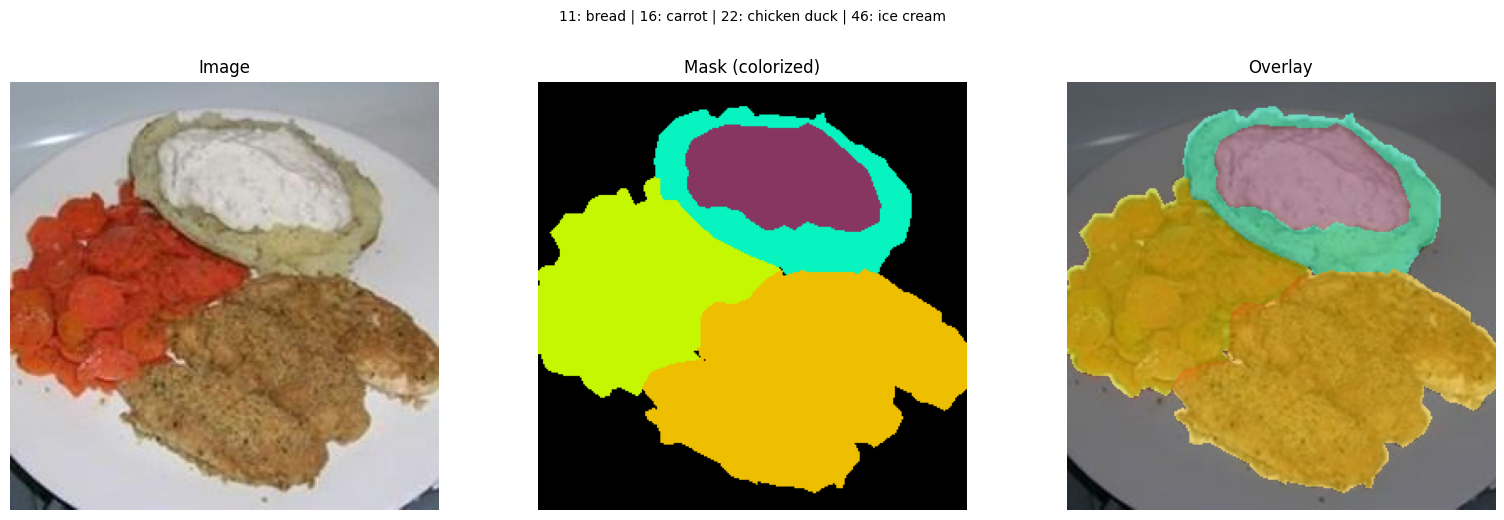

idx=1668 | 00006065.jpg


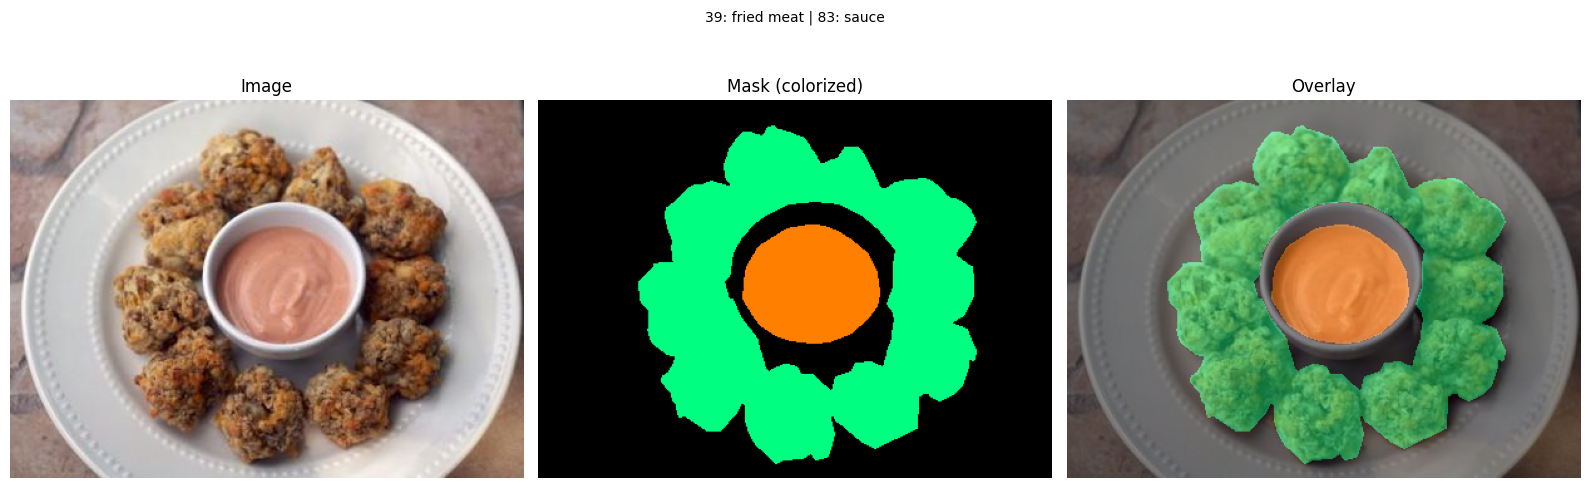

In [6]:
# Visual check on several random train/test samples
rng = random.Random(123)

train_indices = [rng.randrange(len(train_ds)) for _ in range(2)]
test_indices = [rng.randrange(len(test_ds)) for _ in range(2)]

print("Train examples")
for idx in train_indices:
    img_t, mask_t, info = train_ds[idx]
    print(f"idx={idx} | {Path(info['image_path']).name}")
    show_sample(img_t, mask_t, train_id_to_class_name, train_id_to_color, alpha=0.45)

print("Test examples")
for idx in test_indices:
    img_t, mask_t, info = test_ds[idx]
    print(f"idx={idx} | {Path(info['image_path']).name}")
    show_sample(img_t, mask_t, train_id_to_class_name, train_id_to_color, alpha=0.45)